#**Regression**

**Importing Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

**Dataset Loading**

In [ ]:
data = pd.read_csv('/content/drive/My Drive/Sem5/ml/a2/train.csv')
target_col = 'Loan Sanction Amount (USD)'
data.describe()

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


#**EDA**

#**(i). Missing values**

In [ ]:
null_count = dict(data.isnull().sum())
print(null_count)

{'Customer ID': np.int64(0), 'Name': np.int64(0), 'Gender': np.int64(53), 'Age': np.int64(0), 'Income (USD)': np.int64(4576), 'Income Stability': np.int64(1683), 'Profession': np.int64(0), 'Type of Employment': np.int64(7270), 'Location': np.int64(0), 'Loan Amount Request (USD)': np.int64(0), 'Current Loan Expenses (USD)': np.int64(172), 'Expense Type 1': np.int64(0), 'Expense Type 2': np.int64(0), 'Dependents': np.int64(2493), 'Credit Score': np.int64(1703), 'No. of Defaults': np.int64(0), 'Has Active Credit Card': np.int64(1566), 'Property ID': np.int64(0), 'Property Age': np.int64(4850), 'Property Type': np.int64(0), 'Property Location': np.int64(356), 'Co-Applicant': np.int64(0), 'Property Price': np.int64(0), 'Loan Sanction Amount (USD)': np.int64(340)}


**Plotting Histogram for all columns**

In [ ]:
'''for col in data.columns[2:]:                  # Depending on Data
  sns.histplot(data[col],kde=True)
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()'''

'for col in data.columns[2:]:                  # Depending on Data\n  sns.histplot(data[col],kde=True)\n  plt.xticks(rotation=90)\n  plt.tight_layout()\n  plt.show()'

**Columns Name separation**

In [ ]:
col = list(data.columns)

In [ ]:
categorical_col = [i for i in col if (len(data[i].unique())<25 )] #and not data[i].dtype==np.int64)]

categorical_col

['Gender',
 'Income Stability',
 'Profession',
 'Type of Employment',
 'Location',
 'Expense Type 1',
 'Expense Type 2',
 'Dependents',
 'No. of Defaults',
 'Has Active Credit Card',
 'Property Type',
 'Property Location',
 'Co-Applicant']

In [ ]:
#categorical_num_col = [i for i in col if (len(data[i].unique())<25 and data[i].dtype==np.int64)]

#categorical_num_col

In [ ]:
rem_col = [i for i in col if i not in categorical_col and null_count[i]>0]
print(rem_col)

['Income (USD)', 'Current Loan Expenses (USD)', 'Credit Score', 'Property Age', 'Loan Sanction Amount (USD)']


**Imputation for Categorical Columns(Mode)**

In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')

for i in categorical_col:
  data[[i]] = cat_imputer.fit_transform(data[[i]])

In [ ]:
data.isnull().sum()

,0
Customer ID,0
Name,0
Gender,0
Age,0
Income (USD),4576
Income Stability,0
Profession,0
Type of Employment,0
Location,0
Loan Amount Request (USD),0


**Imputation for Categorical numeric Columns**

In [ ]:
#for i in categorical_num_col:
#  data[i] = data[i].fillna(data[i].mode()[0])

**Imputation for non-Categorical Columns(mean)**

In [ ]:
mean_imputer = SimpleImputer(strategy='mean')

for i in rem_col:
  if not i==target_col:
    data[i] = mean_imputer.fit_transform(data[[i]])

**Dropping entire row if target column has null value**

In [ ]:
data = data.dropna(subset=[target_col])

**Null value count in each column**

In [ ]:
data.isnull().sum()

,0
Customer ID,0
Name,0
Gender,0
Age,0
Income (USD),0
Income Stability,0
Profession,0
Type of Employment,0
Location,0
Loan Amount Request (USD),0


**Data(x) and target(y) separation**

In [ ]:
x = data.iloc[:,:-1]

In [ ]:
y = data.loc[:,target_col]

#---------- Data Specific ---------

**Removing Unwanted Features like Name,etc,..**

In [ ]:
x.drop('Name',axis=1,inplace=True)
x.drop('Customer ID',axis=1,inplace=True)
x.drop('Gender',axis=1,inplace=True)
x.drop('Age',axis=1,inplace=True)
x.drop('Property ID',axis=1,inplace=True)
x.drop('Expense Type 1',axis=1,inplace=True)
x.drop('Expense Type 2',axis=1,inplace=True)
x.drop('Type of Employment',axis=1,inplace=True)
x.drop('Has Active Credit Card',axis=1,inplace=True)
x.drop('Co-Applicant',axis=1,inplace=True)

In [ ]:
x.isnull().sum()

,0
Income (USD),0
Income Stability,0
Profession,0
Location,0
Loan Amount Request (USD),0
Current Loan Expenses (USD),0
Dependents,0
Credit Score,0
No. of Defaults,0
Property Age,0


In [ ]:
#for i in x.columns:
#  print(i,x[i].unique)

#------- Data Specific --------

**Label Encoding for String values**

In [ ]:
str_cat = ['Income Stability','Property Type','Location','Profession','Property Location']

x = pd.get_dummies(x,columns=str_cat,drop_first=True)

x

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Price,Income Stability_Low,Property Type_2,...,Location_Urban,Profession_Commercial associate,Profession_Maternity leave,Profession_Pensioner,Profession_State servant,Profession_Student,Profession_Unemployed,Profession_Working,Property Location_Semi-Urban,Property Location_Urban
0,1933.050000,72809.58,241.08,3.0,809.440000,0,1933.05000,119933.46,True,False,...,False,False,False,False,False,False,False,True,False,False
1,4952.910000,46837.47,495.81,1.0,780.400000,0,4952.91000,54791.00,True,True,...,False,False,False,False,False,False,False,True,False,False
2,988.190000,45593.04,171.95,1.0,833.150000,0,988.19000,72440.58,False,True,...,False,False,False,True,False,False,False,False,False,True
3,2630.574417,80057.92,298.54,2.0,832.700000,1,2631.11944,121441.51,False,True,...,False,False,False,True,False,False,False,False,True,False
4,2614.770000,113858.89,491.41,2.0,745.550000,1,2614.77000,208567.91,True,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,76657.90,722.34,2.0,869.610000,0,4969.41000,111096.56,True,False,...,True,True,False,False,False,False,False,False,False,True
29996,1606.880000,66595.14,253.04,3.0,729.410000,0,1606.88000,73453.94,True,False,...,False,False,False,False,False,False,False,True,False,True
29997,2630.574417,81410.08,583.11,2.0,739.885381,0,2631.11944,102108.02,True,False,...,True,False,False,False,False,False,False,True,False,False
29998,2417.710000,142524.10,378.29,3.0,677.270000,1,2417.71000,168194.47,True,False,...,False,False,False,False,False,False,False,True,False,True


In [ ]:
for col in x.columns:
    if x[col].dtype == 'bool':
        x[col] = x[col].astype(int)

In [ ]:
x

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Price,Income Stability_Low,Property Type_2,...,Location_Urban,Profession_Commercial associate,Profession_Maternity leave,Profession_Pensioner,Profession_State servant,Profession_Student,Profession_Unemployed,Profession_Working,Property Location_Semi-Urban,Property Location_Urban
0,1933.050000,72809.58,241.08,3.0,809.440000,0,1933.05000,119933.46,1,0,...,0,0,0,0,0,0,0,1,0,0
1,4952.910000,46837.47,495.81,1.0,780.400000,0,4952.91000,54791.00,1,1,...,0,0,0,0,0,0,0,1,0,0
2,988.190000,45593.04,171.95,1.0,833.150000,0,988.19000,72440.58,0,1,...,0,0,0,1,0,0,0,0,0,1
3,2630.574417,80057.92,298.54,2.0,832.700000,1,2631.11944,121441.51,0,1,...,0,0,0,1,0,0,0,0,1,0
4,2614.770000,113858.89,491.41,2.0,745.550000,1,2614.77000,208567.91,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,76657.90,722.34,2.0,869.610000,0,4969.41000,111096.56,1,0,...,1,1,0,0,0,0,0,0,0,1
29996,1606.880000,66595.14,253.04,3.0,729.410000,0,1606.88000,73453.94,1,0,...,0,0,0,0,0,0,0,1,0,1
29997,2630.574417,81410.08,583.11,2.0,739.885381,0,2631.11944,102108.02,1,0,...,1,0,0,0,0,0,0,1,0,0
29998,2417.710000,142524.10,378.29,3.0,677.270000,1,2417.71000,168194.47,1,0,...,0,0,0,0,0,0,0,1,0,1


#**(ii). Outlier Treatment**

#------- Data Specific --------

In [ ]:
z = x

outlier_column = ['Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'Property Age', 'Property Type',
       'Property Price']


for col in x.columns:
  if col in outlier_column:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    x[col] = x[col].clip(low, high)
x

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Price,Income Stability_Low,Property Type_2,...,Location_Urban,Profession_Commercial associate,Profession_Maternity leave,Profession_Pensioner,Profession_State servant,Profession_Student,Profession_Unemployed,Profession_Working,Property Location_Semi-Urban,Property Location_Urban
0,1933.050000,72809.58,241.08,3.0,809.440000,0,1933.05000,119933.46,1,0,...,0,0,0,0,0,0,0,1,0,0
1,4561.072500,46837.47,495.81,1.0,780.400000,0,4503.23375,54791.00,1,1,...,0,0,0,0,0,0,0,1,0,0
2,988.190000,45593.04,171.95,1.0,833.150000,0,988.19000,72440.58,0,1,...,0,0,0,1,0,0,0,0,0,1
3,2630.574417,80057.92,298.54,2.0,832.700000,1,2631.11944,121441.51,0,1,...,0,0,0,1,0,0,0,0,1,0
4,2614.770000,113858.89,491.41,2.0,745.550000,1,2614.77000,208567.91,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4561.072500,76657.90,722.34,2.0,869.610000,0,4503.23375,111096.56,1,0,...,1,1,0,0,0,0,0,0,0,1
29996,1606.880000,66595.14,253.04,3.0,729.410000,0,1606.88000,73453.94,1,0,...,0,0,0,0,0,0,0,1,0,1
29997,2630.574417,81410.08,583.11,2.0,739.885381,0,2631.11944,102108.02,1,0,...,1,0,0,0,0,0,0,1,0,0
29998,2417.710000,142524.10,378.29,3.0,677.270000,1,2417.71000,168194.47,1,0,...,0,0,0,0,0,0,0,1,0,1


In [ ]:
x.columns

Index(['Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property Age', 'Property Price',
       'Income Stability_Low', 'Property Type_2', 'Property Type_3',
       'Property Type_4', 'Location_Semi-Urban', 'Location_Urban',
       'Profession_Commercial associate', 'Profession_Maternity leave',
       'Profession_Pensioner', 'Profession_State servant',
       'Profession_Student', 'Profession_Unemployed', 'Profession_Working',
       'Property Location_Semi-Urban', 'Property Location_Urban'],
      dtype='object')

#**(iii) Standarization / Normalization**

#------ Data Specific -------

In [ ]:
x_stand = x

column = ['Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property Age', 'Property Price',]

Standard_scale = StandardScaler()

for col in column:
  x_stand[col] = Standard_scale.fit_transform(x_stand[[col]])

x_stand

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Price,Income Stability_Low,Property Type_2,...,Location_Urban,Profession_Commercial associate,Profession_Maternity leave,Profession_Pensioner,Profession_State servant,Profession_Student,Profession_Unemployed,Profession_Working,Property Location_Semi-Urban,Property Location_Urban
0,-0.556419,-0.266582,-0.787101,0.881368,0.992788,-0.490710,-0.562482,-0.112344,1,0,...,0,0,0,0,0,0,0,1,0,0
1,2.202677,-0.729023,0.463085,-1.385880,0.578465,-0.490710,2.173317,-0.866411,1,1,...,0,0,0,0,0,0,0,1,0,0
2,-1.548404,-0.751180,-1.126384,-1.385880,1.331067,-0.490710,-1.568226,-0.662106,0,1,...,0,0,0,1,0,0,0,0,0,1
3,0.175895,-0.137523,-0.505094,-0.252256,1.324646,2.037863,0.180569,-0.094887,0,1,...,0,0,0,1,0,0,0,0,1,0
4,0.159302,0.464313,0.441490,-0.252256,0.081249,2.037863,0.163166,0.913660,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2.202677,-0.198061,1.574869,-0.252256,1.851254,-0.490710,2.173317,-0.214637,1,0,...,1,1,0,0,0,0,0,0,0,1
29996,-0.898857,-0.377232,-0.728403,0.881368,-0.149026,-0.490710,-0.909670,-0.650375,1,0,...,0,0,0,0,0,0,0,1,0,1
29997,0.175895,-0.113447,0.891544,-0.252256,0.000430,-0.490710,0.180569,-0.318685,1,0,...,1,0,0,0,0,0,0,1,0,0
29998,-0.047586,0.974706,-0.113690,0.881368,-0.892925,2.037863,-0.046592,0.446310,1,0,...,0,0,0,0,0,0,0,1,0,1


In [ ]:
x_min   = x

minmax_scale = MinMaxScaler()

for col in column:
  x_min[[col]] = minmax_scale.fit_transform(x_min[[col]])

x_min

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Price,Income Stability_Low,Property Type_2,...,Location_Urban,Profession_Commercial associate,Profession_Maternity leave,Profession_Pensioner,Profession_State servant,Profession_Student,Profession_Unemployed,Profession_Working,Property Location_Semi-Urban,Property Location_Urban
0,0.371793,0.287915,0.367962,0.571429,0.725479,0.0,0.377006,0.338732,1,0,...,0,0,0,0,0,0,0,1,0,0
1,1.000000,0.175908,0.602706,0.000000,0.633656,0.0,1.000000,0.156268,1,1,...,0,0,0,0,0,0,0,1,0,0
2,0.145932,0.170541,0.304256,0.000000,0.800449,0.0,0.147978,0.205704,0,1,...,0,0,0,1,0,0,0,0,0,1
3,0.538531,0.319174,0.420913,0.285714,0.799026,1.0,0.546213,0.342956,0,1,...,0,0,0,1,0,0,0,0,1,0
4,0.534753,0.464944,0.598651,0.285714,0.523462,1.0,0.542250,0.586996,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1.000000,0.304511,0.811462,0.285714,0.915734,0.0,1.000000,0.313979,1,0,...,1,1,0,0,0,0,0,0,0,1
29996,0.293825,0.261115,0.378983,0.571429,0.472428,0.0,0.297944,0.208543,1,0,...,0,0,0,0,0,0,0,1,0,1
29997,0.538531,0.325005,0.683156,0.285714,0.505550,0.0,0.546213,0.288803,1,0,...,1,0,0,0,0,0,0,1,0,0
29998,0.487647,0.588566,0.494406,0.571429,0.307563,1.0,0.494484,0.473911,1,0,...,0,0,0,0,0,0,0,1,0,1


#**Train Test Validation Split**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_stand,y,test_size=0.5,random_state=42)

In [ ]:
x_val,x_test,y_val,y_test = train_test_split(x_test,y_test,test_size=0.2,random_state=42)

#**Model Training**

#-------- Model Specific --------

In [ ]:
model = SVR(kernel='linear')
model.fit(x_train,y_train)

SVR(kernel='linear')

In [ ]:
y_pre_train = model.predict(x_train)
print("R2 score of Training : ",model.score(x_train,y_train))

R2 score of Training :  -0.02354549472093903


In [ ]:
print(model.get_params())

{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


#**Grid Search CV**

In [ ]:
params = {
          'degree': [1,2,3,4,5] ,
          'kernel': ['linear','poly','sigmoid','rbf']
        }

grid = GridSearchCV(model, param_grid=params, cv=5)
grid.fit(x_val, y_val)

print(grid.best_params_)
print(grid.best_score_)

KeyboardInterrupt: 

#**Randomized Search CV**

In [ ]:
param_distributions = {
     'degree': [1,2,3,4,5] ,
     'kernel': ['linear','poly','sigmoid','rbf']
}

random = RandomizedSearchCV(model, param_distributions=param_distributions, cv=5)
random.fit(x_val, y_val)

print(random.best_params_)
print(random.best_score_)

In [ ]:
'''from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['poly', 'rbf', 'linear'],
    'svr__degree': [2, 3, 4, 5],
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto']
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_val, y_val)
print(grid.best_params_, grid.best_score_)'''

**HyperParameters Fine Tuned Model**

In [ ]:
model = SVR(degree = 5, kernel = 'poly')
model.fit(x_train,y_train)

SVR(degree=5, kernel='poly')

#**Testing**

In [ ]:
y_pre_test = model.predict(x_test)

In [ ]:
r2_test = r2_score(y_test.values,y_pre_test)
mse_test = mean_squared_error(y_test.values,y_pre_test)
mae_test = mean_absolute_error(y_test.values,y_pre_test)
rmse_test = root_mean_squared_error(y_test,y_pre_test)

In [ ]:
print("Mean Squared Error for Testing      :",mse_test)
print("Mean Absolute Error for Testing     :",mae_test)
print("Root Mean Squared Error for Testing :",rmse_test)
print("R2 score for Testing                :",r2_test)

Mean Squared Error for Testing      : 1949359399.14364
Mean Absolute Error for Testing     : 34206.765949058376
Root Mean Squared Error for Testing : 44151.55035945669
R2 score for Testing                : 0.11574843268209134


In [ ]:
n = x_min.shape[0]
p = x_min.shape[1]

adjusted_r2_test = 1-((1-r2_test)*(n-1)/(n-p-1))

In [ ]:
print("Adjusted R2 Score for Testing :",adjusted_r2_test)

Adjusted R2 Score for Testing : 0.11506217994729873


**Visualization**

In [ ]:
print("\nIntercept of Model :",model.intercept_)


Intercept of Model : [32223.35621249]


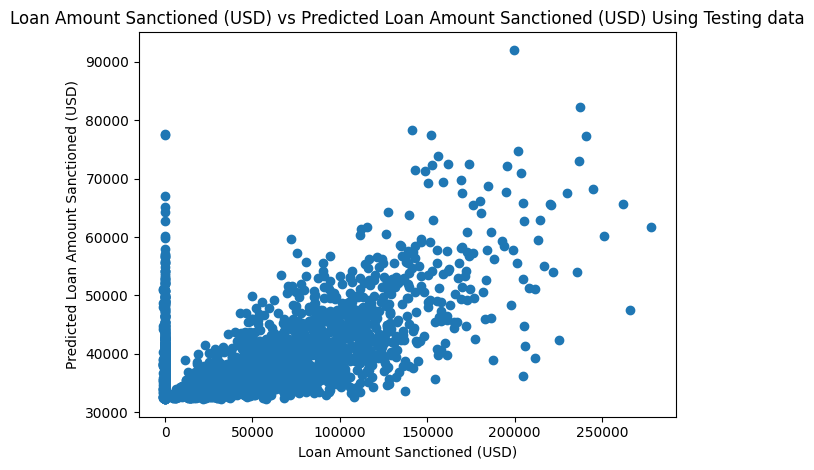

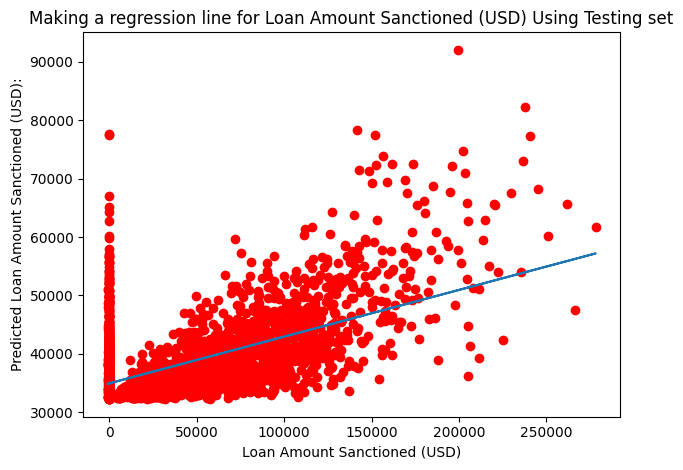

In [ ]:
def slope_intercept(x_val,y_val):
  x=np.array(x_val)
  y=np.array(y_val)
  m=(((np.mean(x)*np.mean(y)) - np.mean(x*y)) / ((np.mean(x)*np.mean(x)) -np.mean(x*x)))
  m=round(m,2)
  b=(np.mean(y) - np.mean(x)*m)
  b=round(b,2)
  #print("Slope :",m,"\tIntercept :",b)
  return m,b


plt.scatter(y_test,y_pre_test)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD)")
plt.title("Loan Amount Sanctioned (USD) vs Predicted Loan Amount Sanctioned (USD) Using Testing data")
plt.tight_layout()
plt.show()
print()

m,b=slope_intercept(y_test, y_pre_test)
reg_line=[(m*x)+b for x in y_test.values]
plt.scatter(y_test,y_pre_test,color="red")
plt.plot(y_test,reg_line)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD):")
plt.title("Making a regression line for Loan Amount Sanctioned (USD) Using Testing set")
plt.tight_layout()
#plt.savefig('/content/drive/My Drive/Sem5/ml/a2/residual_plot.png')
plt.show()
print()

#**Cross Validation**

In [ ]:
from sklearn.model_selection import cross_validate

results = cross_validate(model,x_val,y_val,cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error','neg_root_mean_squared_error'])

In [ ]:
df = pd.DataFrame(results)
df

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error,test_neg_root_mean_squared_error
0,3.806463,0.632088,0.047169,-2.174498e+09,-36058.933210,-46631.511121
1,3.752742,0.619488,0.053311,-2.108091e+09,-34928.617294,-45913.956823
2,5.222767,0.618115,0.067362,-2.162352e+09,-34908.659750,-46501.094332
3,3.740610,0.622388,0.051745,-2.195666e+09,-36227.976175,-46857.930031
4,3.684958,0.623635,0.052335,-2.083430e+09,-35165.265061,-45644.608433


**Another Method for KFold Validation**

In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = SVR()

mse_scores = []
mae_scores = []
sse_scores = []
rmse_scores = []
r2_scores = []
adjusted_r2_scores = []


for train_index, test_index in kf.split(x):
    x_train, x_test = x_min.iloc[train_index], x_min.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    sse = np.sum((y_test.values - y_pred)**2)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

    mse_scores.append(mse)
    sse_scores.append(sse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    adjusted_r2_scores.append(adjusted_r2)

df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'mse_scores': mse_scores,
    'mae_scores': mae_scores,
    'sse_scores': sse_scores,
    'rmse_scores': rmse_scores,
    'r2_scores': r2_scores,
    'adjusted_r2_scores': adjusted_r2_scores
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'mse_scores': np.mean(mse_scores),
    'mae_scores': np.mean(mae_scores),
    'sse_scores': np.mean(sse_scores),
    'rmse_scores': np.mean(rmse_scores),
    'r2_scores': np.mean(r2_scores),
    'adjusted_r2_scores': np.mean(adjusted_r2_scores)
}])

df = pd.concat([df, mean_row], ignore_index=True)

In [54]:
df

,KFold,mse_scores,mae_scores,sse_scores,rmse_scores,r2_scores,adjusted_r2_scores
0,1,2.409200e+09,36789.698827,1.429137e+13,49083.601283,-0.061427,-0.062251
1,2,2.387514e+09,36974.212944,1.416274e+13,48862.198539,-0.052365,-0.053181
2,3,2.435911e+09,36894.077553,1.444982e+13,49354.948962,-0.055079,-0.055897
3,4,2.548833e+09,37620.782196,1.511968e+13,50485.967135,-0.054709,-0.055527
4,5,2.497432e+09,37428.710056,1.481477e+13,49974.311702,-0.057483,-0.058304
5,Mean,2.455778e+09,37141.496315,1.456768e+13,49552.205524,-0.056212,-0.057032


In [55]:
pd.set_option('display.float_format', '{:.5f}'.format)